# Note that this project takes place in R

![Dr. Semmelweis](ignaz_semmelweis_1860.jpeg)

Hungarian physician Dr. Ignaz Semmelweis worked at the Vienna General Hospital with childbed fever patients. Childbed fever is a deadly disease affecting women who have just given birth, and in the early 1840s, as many as 10% of the women giving birth died from it at the Vienna General Hospital. Dr.Semmelweis discovered that it was the contaminated hands of the doctors delivering the babies, and on June 1st, 1847, he decreed that everyone should wash their hands, an unorthodox and controversial request; nobody in Vienna knew about bacteria.

You will reanalyze the data that made Semmelweis discover the importance of handwashing and its impact on the hospital.

The data is stored as two CSV files within the `data` folder.

`yearly_deaths_by_clinic.csv` contains the number of women giving birth at the two clinics at the Vienna General Hospital between the years 1841 and 1846.

| Column | Description |
|--------|-------------|
|`year`  |Years (1841-1846)|
|`births`|Number of births|
|`deaths`|Number of deaths|
|`clinic`|Clinic 1 or clinic 2|

`monthly_deaths.csv` contains data from 'Clinic 1' of the hospital where most deaths occurred.

| Column | Description |
|--------|-------------|
|`date`|Date (YYYY-MM-DD)
|`births`|Number of births|
|`deaths`|Number of deaths|

In [26]:
# Import libraries
library(tidyverse)
library(dplyr)


In [27]:
#load in data
yearly <- read_csv("yearly_deaths_by_clinic.csv")
monthly <- read_csv("monthly_deaths.csv")

#investigate the 2 datasets
glimpse(yearly)
yearly

glimpse(monthly)
monthly

Rows: 12 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): clinic
dbl (3): year, births, deaths

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 98 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (2): births, deaths
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 12
Columns: 4
$ year   <dbl> 1841, 1842, 1843, 1844, 1845, 1846, 1841, 1842, 1843, 1844, 184…
$ births <dbl> 3036, 3287, 3060, 3157, 3492, 4010, 2442, 2659, 2739, 2956, 324…
$ deaths <dbl> 237, 518, 274, 260, 241, 459, 86, 202, 164, 68, 66, 105
$ clinic <chr> "clinic 1", "clinic 1", "clinic 1", "clinic 1", "clinic 1", "cl…


year,births,deaths,clinic
<dbl>,<dbl>,<dbl>,<chr>
1841,3036,237,clinic 1
1842,3287,518,clinic 1
1843,3060,274,clinic 1
1844,3157,260,clinic 1
1845,3492,241,clinic 1
1846,4010,459,clinic 1
1841,2442,86,clinic 2
1842,2659,202,clinic 2
1843,2739,164,clinic 2


Rows: 98
Columns: 3
$ date   <date> 1841-01-01, 1841-02-01, 1841-03-01, 1841-04-01, 1841-05-01, 18…
$ births <dbl> 254, 239, 277, 255, 255, 200, 190, 222, 213, 236, 235, 307, 311…
$ deaths <dbl> 37, 18, 12, 4, 2, 10, 16, 3, 4, 26, 53, 64, 38, 27, 26, 10, 18,…


date,births,deaths
<date>,<dbl>,<dbl>
1841-01-01,254,37
1841-02-01,239,18
1841-03-01,277,12
1841-04-01,255,4
1841-05-01,255,2
1841-06-01,200,10
1841-07-01,190,16
1841-08-01,222,3
1841-09-01,213,4


# Q1
Add a `proportion_deaths` column to each df, calculating the proportion of deaths per number of births for each year in `yearly` and month in `monthly`.

In [28]:
#Q1
#for each dataset, add a column indicating the proportion of deaths for every birth

#YEARLY
yearly <- yearly %>%
    group_by(year) %>%
    #get proportion of # deaths for every birth
    mutate(proportion_deaths = deaths/births) %>%
    ungroup()

#MONTHLY
monthly <- monthly %>%
    group_by(date) %>%
    #get proportion of # deaths for every birth
    mutate(proportion_deaths = deaths/births) %>%
    ungroup()

# Q2
Create two `ggplot` line plots: one for the yearly proportion of deaths and another for the monthly proportion of deaths. For the yearly plot, create a different colored line for each clinic.

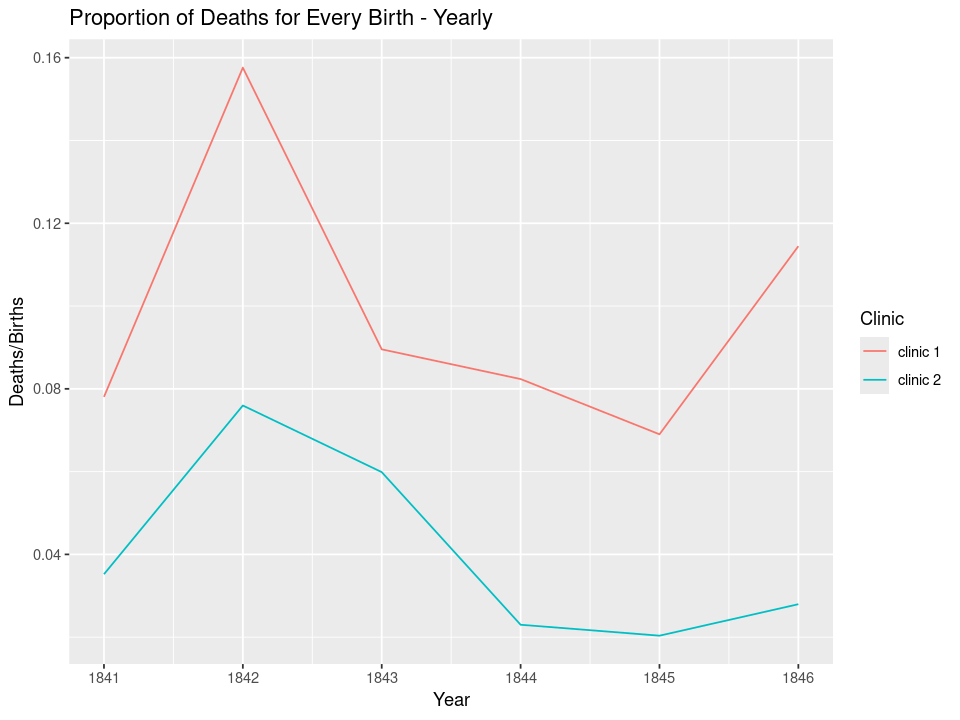

In [29]:
#Q2

#YEARLY
#adjust the figure size
options(repr.plot.width = 8, repr.plot.height = 6)
#plot the data
q2_plot_YR <- ggplot(yearly, aes(x=year, y=proportion_deaths, color=clinic)) + geom_line() +
    labs(title="Proportion of Deaths for Every Birth - Yearly", x='Year', y='Deaths/Births', color='Clinic') +
    theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10),
        axis.title.y=element_text(size=10), legend.title=element_text(size=10))
q2_plot_YR

In the plot above, the proportion of deaths of women who have recently given birth per babies born is illustrated on a yearly basis between 1841-1846. The two lines indicate these quantities for the two different clinics at the Vienne General Hospital.

On a yearly basis, the rate of deaths of post-birth women was notably greater in Clinic 1 than in Clinic 2. Apart from in 1843, this rate in Clinic 1 was at least twice that of Clinic 2. From 1841-1846, this rate was:
- between seven & 16% in Clinic 1,
- between two & eight percent in Clinic 2.

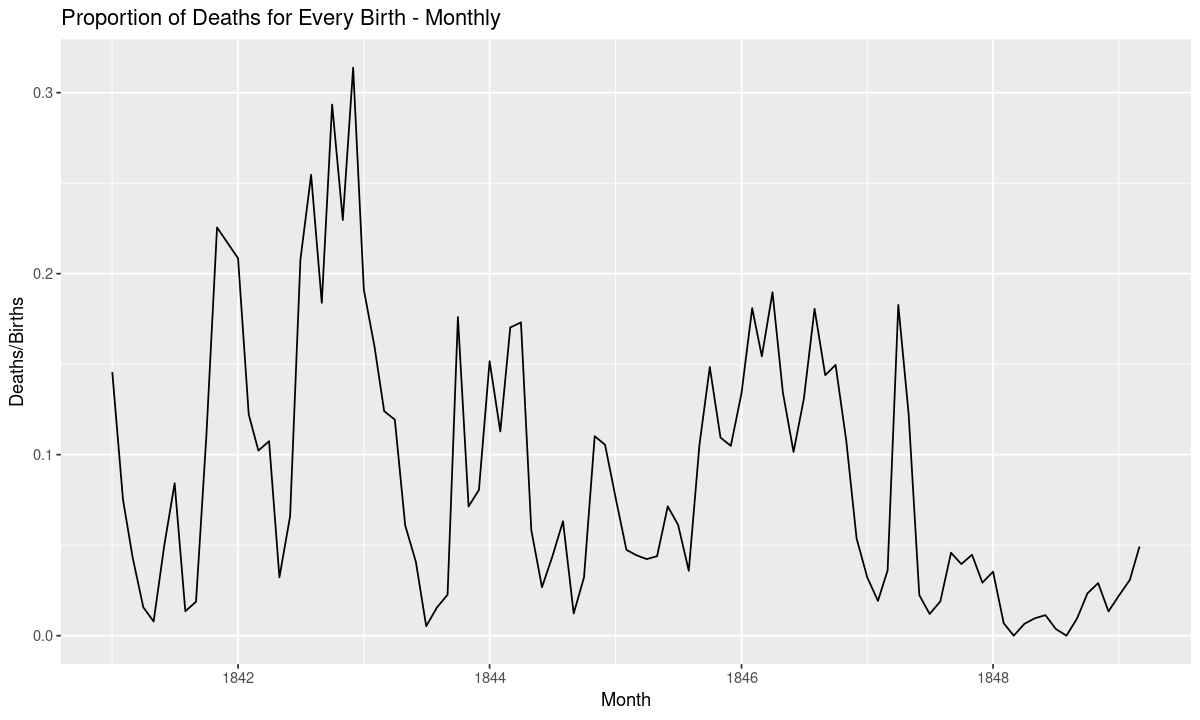

In [30]:
#Q2 cont.

#MONTHLY
#adjust the figure size
options(repr.plot.width = 10, repr.plot.height = 6)
#plot the data
q2_plot_M <-ggplot(monthly, aes(x=date, y=proportion_deaths)) + geom_line() +
    labs(title="Proportion of Deaths for Every Birth - Monthly", x='Month', y='Deaths/Births') +
    theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10),
        axis.title.y=element_text(size=10), legend.title=element_text(size=10))
q2_plot_M

In the plot above, the proportion of deaths of women who have recently given birth per babies born on a monthly basis is illustrated between 1841-1850. 
This rate peaked at the end of 1842 & was at its lowest in 1848. It appears that during this time period, there were two instances (months) in which no women died after giving birth, both of which occurred in 1848. From the first & last month of data, this rate declined from about 15% to about five percent. In other words, in early 1841 at the Vienne General Hospital, about 15 in 100 women died after giving birth. Eight years later, in early 1849, this number had dropped to about five in 100.

# Q3
Add a `handwashing_started` boolean column to `monthly` using June 1st, 1847 as the threshold; TRUE should mean that handwashing has started at the clinic. Plot the new df with different colored lines depending on `handwashing_started`.

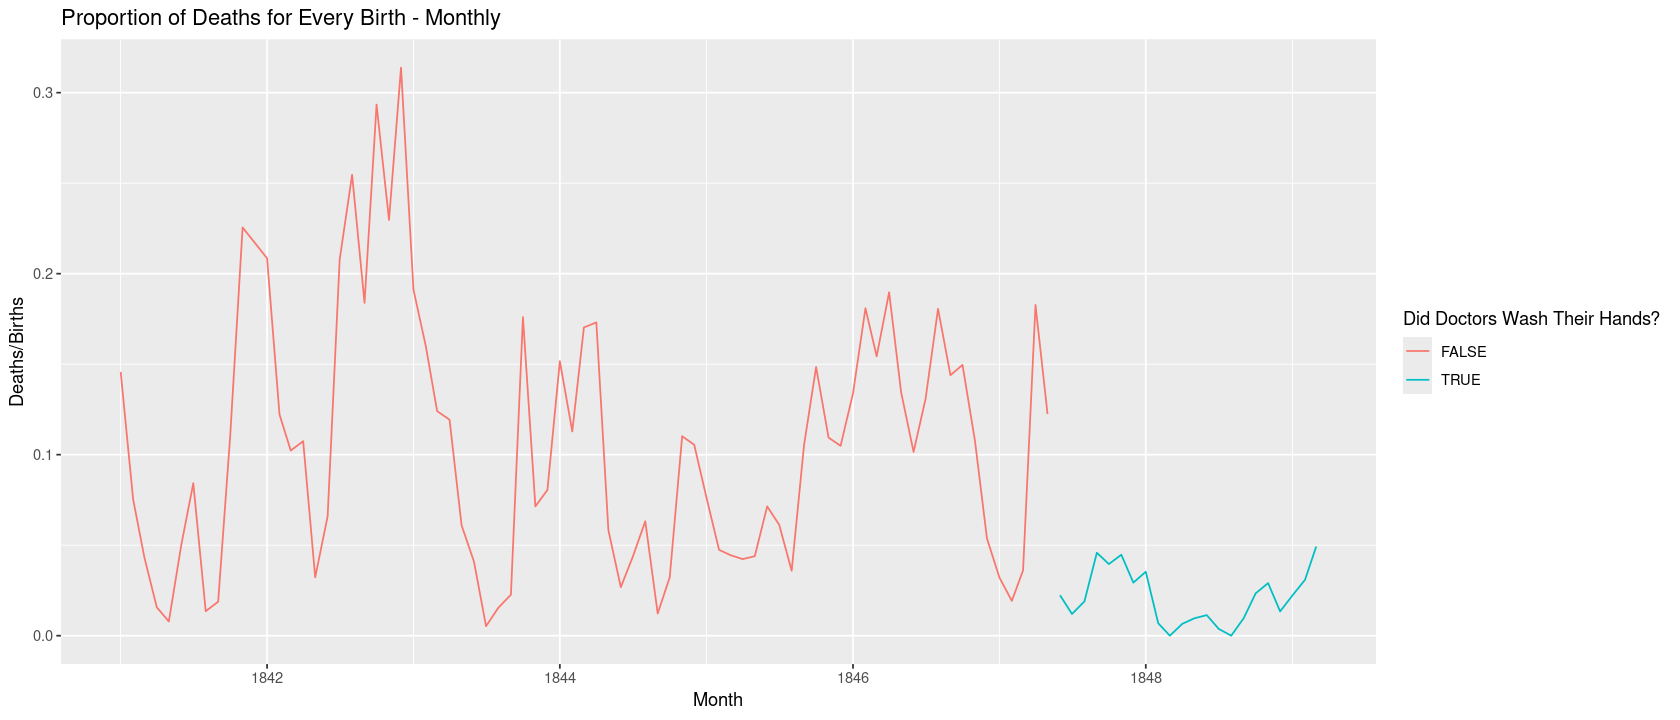

In [31]:
#Q3
#add a column indicating when Dr. Semmelweis made handwashing mandatory
monthly <- monthly %>%
    mutate(handwashing_started = case_when(date < "1847-06-01" ~ FALSE, date >= "1847-06-01" ~ TRUE))

#adjust figure size
options(repr.plot.width = 14, repr.plot.height = 6)
#plot the data
q3_plot_I <- ggplot(monthly, aes(x=date, y=proportion_deaths, color=handwashing_started)) + geom_line() +
    labs(title="Proportion of Deaths for Every Birth - Monthly", x='Month', y='Deaths/Births', 
         color="Did Doctors Wash Their Hands?") +
    theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10),
          axis.title.y=element_text(size=10), legend.title=element_text(size=10))
q3_plot_I

This plot displays the same information as the most previous plot does (in Q3) except for a new detail. Specifically, the color of the plot indicates whether handwashing had been enforced or not at the Vienna General Hospital. Dr. Semmelweis enforced that doctors who delivered babies at the hospital wash their hands on June 1st, 1847.

In segmenting this data with respect to this new detail, Dr. Semmelweis' handwashing mandate appeared to have a powerful influence on the number of women who died after giving birth. Before this date, about 15% of women died for every birth on a monthly basis. Afterwards, this rate dropped to anywhere between 0 & five percent.

# Q4
Calculate the mean proportion of deaths before and after handwashing from the `monthly` data, and store the result as a 2x2 df named `monthly_summary` with the first column containing the `handwashing_started` groups and the second column having the mean proportion of deaths.

In [32]:
#Q4

#get the avg # deaths per birth before & after handwashing became mandatory
monthly_summary <- monthly %>%
    group_by(handwashing_started) %>%
    summarize(avg_deaths_per_births_prop = mean(deaths/births)) %>%
    ungroup()
monthly_summary

handwashing_started,avg_deaths_per_births_prop
<lgl>,<dbl>
FALSE,0.10504998
TRUE,0.02109338


Before Dr. Semmelweis enforced handwashing among doctors at the Vienna General Hospital, about 10.5% of women died soon after giving birth. Once handwashing was made mandatory, on June 1st, 1847, this rate dropped to about 2.11%.